In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define simulation parameters
fs = 1000  # Sampling frequency (Hz)
duration = 1  # Signal duration in seconds
t = np.linspace(0, duration, int(fs * duration))  # Time vector

# Generate clean radar signal
clean_signal = np.sin(2 * np.pi * 10 * t)  # 10 Hz

# Generate interference
interference = 0.5 * np.sin(2 * np.pi * 50 * t)  # 50 Hz

# Composite signal with interference
signal_with_interference = clean_signal + interference


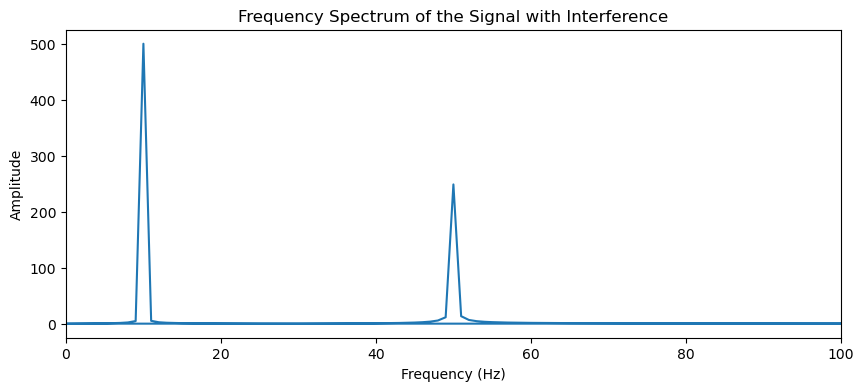

In [2]:
from scipy.fft import fft, fftfreq

# Perform FFT on composite signal
fft_values = fft(signal_with_interference)
fft_freq = fftfreq(len(t), 1 / fs)

# Plot frequency spectrum
plt.figure(figsize=(10, 4))
plt.plot(fft_freq, np.abs(fft_values))
plt.xlim(0, 100)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum of the Signal with Interference")
plt.show()


In [3]:
from scipy.signal import butter, filtfilt

# Define band-stop filter
def band_stop_filter(data, lowcut, highcut, fs, order=2):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype="bandstop")
    return filtfilt(b, a, data)

# Apply the filter
filtered_signal = band_stop_filter(signal_with_interference, 45, 55, fs)


In [4]:
from sklearn.metrics import mean_squared_error

# Calculate MSE
mse_before = mean_squared_error(clean_signal, signal_with_interference)
mse_after = mean_squared_error(clean_signal, filtered_signal)

print(f"MSE Before Filtering: {mse_before:.4f}")
print(f"MSE After Filtering: {mse_after:.4f}")


MSE Before Filtering: 0.1249
MSE After Filtering: 0.0002
